![Portada de la actividad](portada.jpeg)

# ESCUELA DE INGENIERÍA

## Machine Learning

**Unidad 2**

**Integrantes:** Camila Donoso Araya

# Introducción

En esta segunda parte del trabajo se continuó con el desarrollo del problema planteado en la Evaluación 1, enfocándose ahora en el entrenamiento, comparación y evaluación de distintos modelos supervisados de predicción, tal como lo pide la actividad. Para esto, se probaron los modelos Lasso, Ridge, ElasticNet, Random Forest, XGBoost y una red neuronal simple, evaluando su desempeño en entrenamiento, validación y test mediante las métricas $RMSE$ y $R^2$, ya que el problema corresponde a regresión. Posteriormente, se realizó una optimización de hiperparámetros en todos los modelos, con el fin de mejorar su capacidad de generalización y comparar nuevamente sus resultados. Finalmente, el modelo que obtuvo el mejor desempeño fue ElasticNet, ya que después del ajuste de hiperparámetros logró en test un $RMSE = 57.72$ y un $R^2 = 0.63$, lo que muestra que fue el que mejor predijo fuera de muestra. Además, se observó que algunos modelos presentaron sobreajuste, mientras que ElasticNet mostró un comportamiento más estable entre entrenamiento y test, por lo que resultó ser la mejor opción final para este caso.

# DESARROLLO EVALUACIÓN 2

In [1]:
import pandas as pd

train = pd.read_csv("datos/train.csv", parse_dates=["date"])
val = pd.read_csv("datos/val.csv", parse_dates=["date"])
test = pd.read_csv("datos/test.csv", parse_dates=["date"])

print("train:", train.shape)
print("val:", val.shape)
print("test:", test.shape)

train: (1178, 2)
val: (337, 2)
test: (169, 2)


# DESARROLLO
1) Entrena diferentes modelos de Machine Learning (muestra entrenamiento), usando:
    1. Algoritmos de Penalización: Lasso, Ridge o ElasticNet.

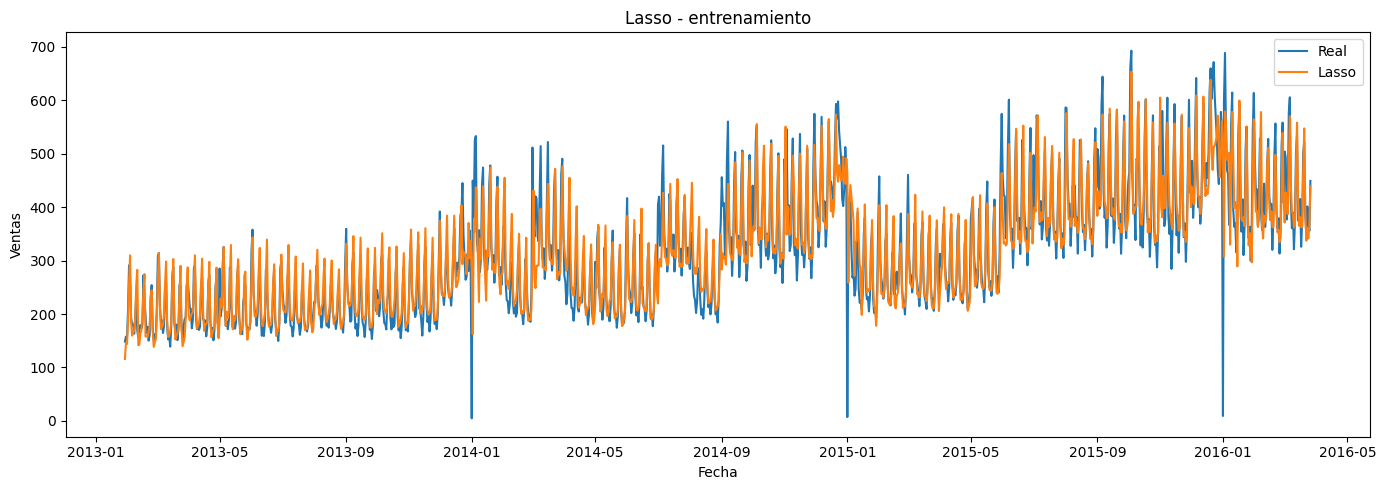

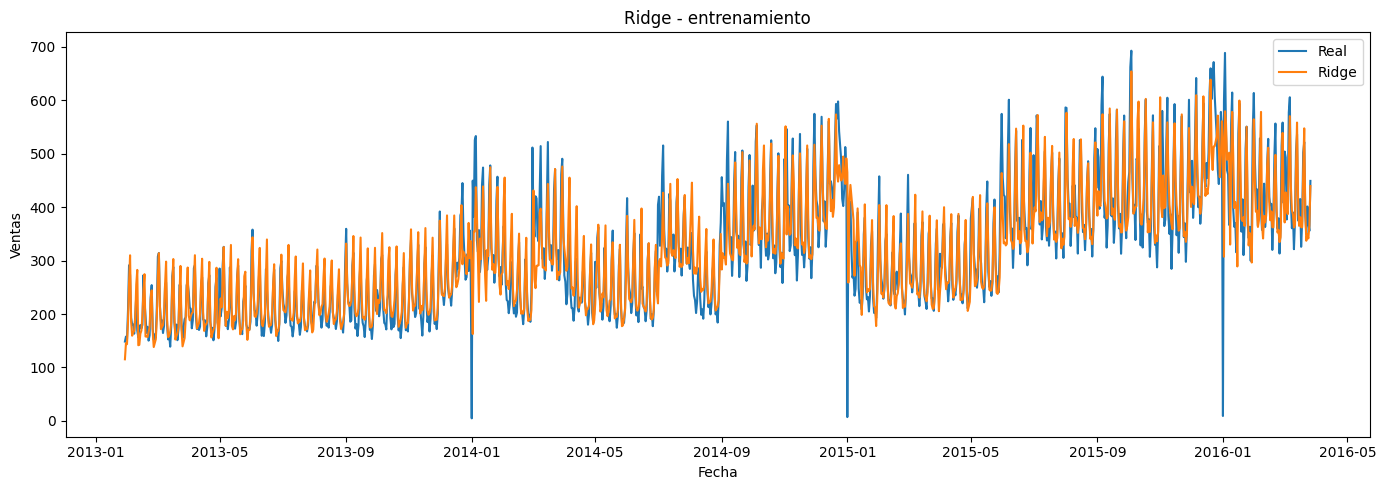

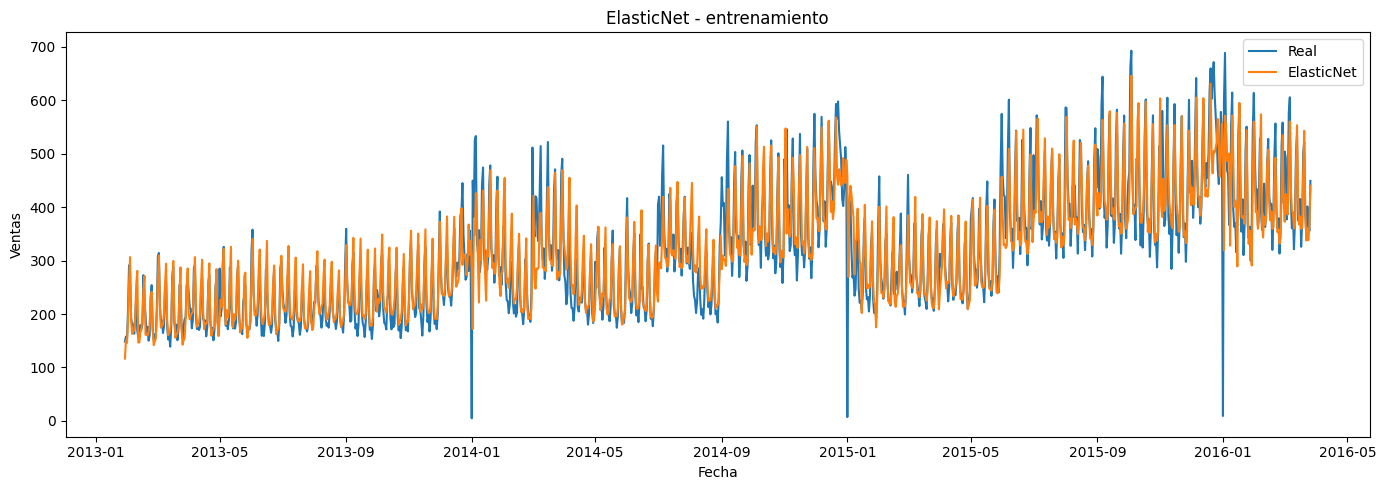

In [3]:
from sklearn.linear_model import Lasso, Ridge, ElasticNet
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

train_model = train.copy().sort_values("date").reset_index(drop=True)

train_model["lag_1"] = train_model["sales"].shift(1)
train_model["lag_7"] = train_model["sales"].shift(7)
train_model["lag_14"] = train_model["sales"].shift(14)
train_model["lag_28"] = train_model["sales"].shift(28)

train_model["dayofweek"] = train_model["date"].dt.dayofweek
train_model["month"] = train_model["date"].dt.month
train_model["day"] = train_model["date"].dt.day

train_model = train_model.dropna().reset_index(drop=True)

features = ["lag_1", "lag_7", "lag_14", "lag_28", "dayofweek", "month", "day"]

X_train = train_model[features]
y_train = train_model["sales"]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

################ LASSO ################

lasso_model = Lasso(alpha=0.1, max_iter=20000)
lasso_model.fit(X_train_scaled, y_train)

coef_lasso = pd.DataFrame({
    "Variable": features,
    "Coeficiente": lasso_model.coef_
})

y_pred_lasso = lasso_model.predict(X_train_scaled)

coef_lasso

################ RIDGE ################

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)

coef_ridge = pd.DataFrame({
    "Variable": features,
    "Coeficiente": ridge_model.coef_
})

y_pred_ridge = ridge_model.predict(X_train_scaled)

coef_ridge

################ ELASTICNET ################

elastic_model = ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=20000)
elastic_model.fit(X_train_scaled, y_train)

coef_elastic = pd.DataFrame({
    "Variable": features,
    "Coeficiente": elastic_model.coef_
})

y_pred_elastic = elastic_model.predict(X_train_scaled)

coef_elastic

################ LASSO ################

plt.figure(figsize=(14, 5))
plt.plot(train_model["date"], y_train, label="Real")
plt.plot(train_model["date"], y_pred_lasso, label="Lasso")
plt.title("Lasso - entrenamiento")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.legend()
plt.tight_layout()
plt.show()

################ RIDGE ################

plt.figure(figsize=(14, 5))
plt.plot(train_model["date"], y_train, label="Real")
plt.plot(train_model["date"], y_pred_ridge, label="Ridge")
plt.title("Ridge - entrenamiento")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.legend()
plt.tight_layout()
plt.show()

################ ELASTICNET ################

plt.figure(figsize=(14, 5))
plt.plot(train_model["date"], y_train, label="Real")
plt.plot(train_model["date"], y_pred_elastic, label="ElasticNet")
plt.title("ElasticNet - entrenamiento")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.legend()
plt.tight_layout()
plt.show()

El ajuste de los tres modelos de regresión, son bastante buenos (bastante tanto que pensaria en un sobre ajuste de los modelos a los datos de entrenamiento).

### 2. Algoritmo Random Forest.

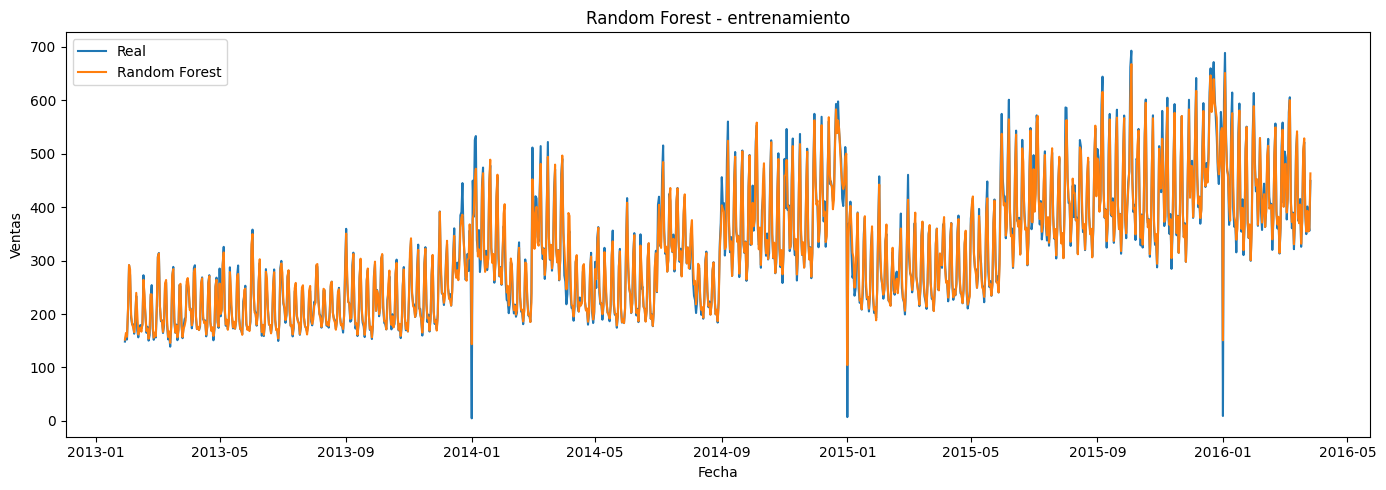

In [4]:
from sklearn.ensemble import RandomForestRegressor
################ RANDOM FOREST ################

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

imp_rf = pd.DataFrame({
    "Variable": features,
    "Importancia": rf_model.feature_importances_
})

imp_rf
y_pred_rf = rf_model.predict(X_train)

plt.figure(figsize=(14, 5))
plt.plot(train_model["date"], y_train, label="Real")
plt.plot(train_model["date"], y_pred_rf, label="Random Forest")
plt.title("Random Forest - entrenamiento")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.legend()
plt.tight_layout()
plt.show()

En la gráfica con el modelo ajustado, puedo observar, que el ajuste de los valores en los dias finales del año esta mejor, se ajusta mejor a los valores extremos de las series.

### 3. Algoritmos XGBoost.

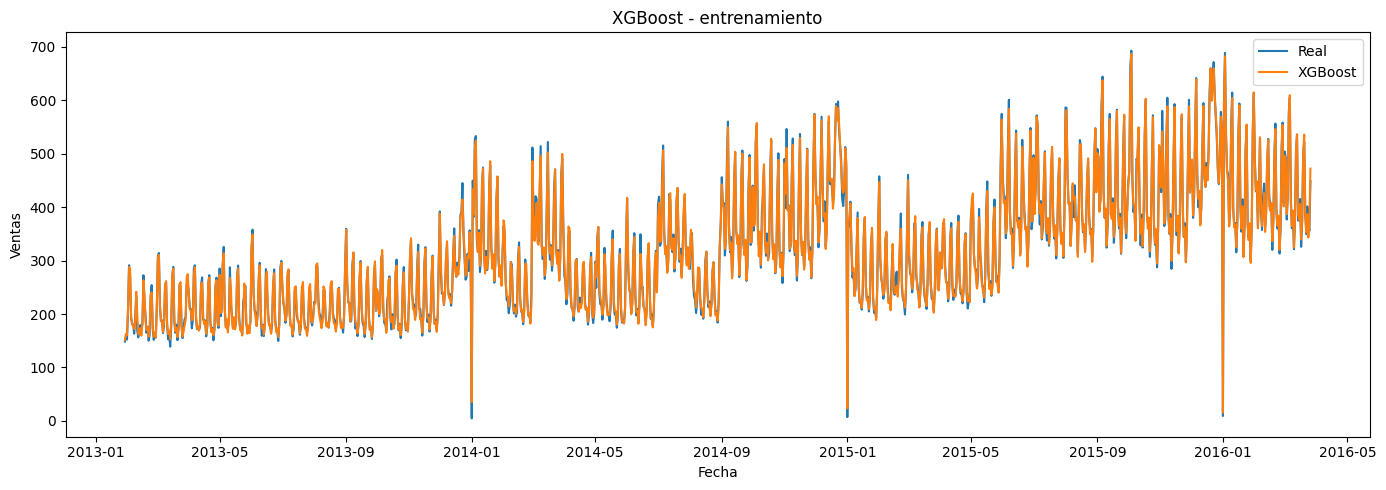

In [5]:
from xgboost import XGBRegressor
################ XGBOOST ################

xgb_model = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

imp_xgb = pd.DataFrame({
    "Variable": features,
    "Importancia": xgb_model.feature_importances_
})

imp_xgb
y_pred_xgb = xgb_model.predict(X_train)

plt.figure(figsize=(14, 5))
plt.plot(train_model["date"], y_train, label="Real")
plt.plot(train_model["date"], y_pred_xgb, label="XGBoost")
plt.title("XGBoost - entrenamiento")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.legend()
plt.tight_layout()
plt.show()

Observamos que el algoritmo XGBoost sobre ajusta los datos. La literatura coloca este algoritmo como el mejor pero observando en estos datos, parece 

### 4. Red Neuronal simple.

In [7]:
from sklearn.neural_network import MLPRegressor
################ RED NEURONAL SIMPLE ################

nn_model = MLPRegressor(
    hidden_layer_sizes=(64,),
    activation="relu",
    solver="adam",
    max_iter=2000,
    random_state=42
)

nn_model.fit(X_train_scaled, y_train)

y_pred_nn = nn_model.predict(X_train_scaled)

c:\Users\kkkkn\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


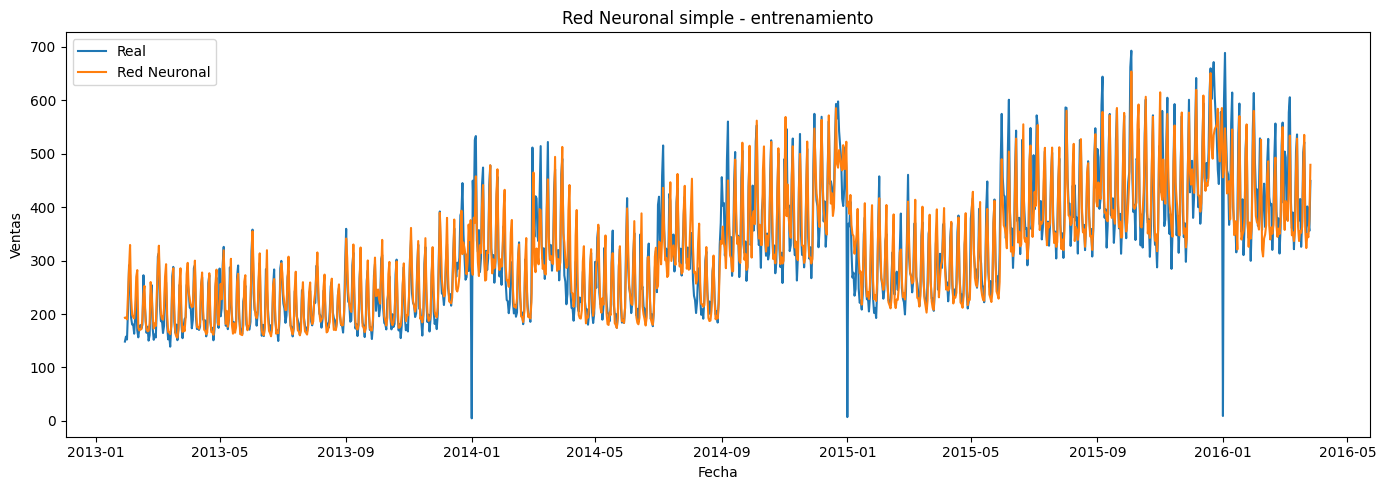

In [8]:
plt.figure(figsize=(14, 5))
plt.plot(train_model["date"], y_train, label="Real")
plt.plot(train_model["date"], y_pred_nn, label="Red Neuronal")
plt.title("Red Neuronal simple - entrenamiento")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.legend()
plt.tight_layout()
plt.show()

Es interesante observar que no sobre ajusta los valores extremos como lo hace el algoritmo de Random Forest

### 2) Calcular las métricas de desempeño más relevantes: Accuracy, Precision, Recall, F1-Score, AUC, KS, R2 o RMSE según sea el caso. Usando muestra entrenamiento y validación.

Como se tiene una serie de tiempo, las métricas que podemos utilizar son RMSE y R2

$$
RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}
$$


$$
R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{n}(y_i - \bar{y})^2}
$$

In [13]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
val_model = val.copy().sort_values("date").reset_index(drop=True)

val_model["lag_1"] = val_model["sales"].shift(1)
val_model["lag_7"] = val_model["sales"].shift(7)
val_model["lag_14"] = val_model["sales"].shift(14)
val_model["lag_28"] = val_model["sales"].shift(28)

val_model["dayofweek"] = val_model["date"].dt.dayofweek
val_model["month"] = val_model["date"].dt.month
val_model["day"] = val_model["date"].dt.day

val_model = val_model.dropna().reset_index(drop=True)

X_val = val_model[features]
y_val = val_model["sales"]

X_val_scaled = scaler.transform(X_val)

y_pred_lasso_val = lasso_model.predict(X_val_scaled)
y_pred_ridge_val = ridge_model.predict(X_val_scaled)
y_pred_elastic_val = elastic_model.predict(X_val_scaled)
y_pred_rf_val = rf_model.predict(X_val)
y_pred_xgb_val = xgb_model.predict(X_val)
y_pred_nn_val = nn_model.predict(X_val_scaled)

metricas = pd.DataFrame({
    "Modelo": ["Lasso", "Ridge", "ElasticNet", "Random Forest", "XGBoost", "Red Neuronal"],

    "RMSE_train": [
        np.sqrt(mean_squared_error(y_train, y_pred_lasso)),
        np.sqrt(mean_squared_error(y_train, y_pred_ridge)),
        np.sqrt(mean_squared_error(y_train, y_pred_elastic)),
        np.sqrt(mean_squared_error(y_train, y_pred_rf)),
        np.sqrt(mean_squared_error(y_train, y_pred_xgb)),
        np.sqrt(mean_squared_error(y_train, y_pred_nn))
    ],

    "R2_train": [
        r2_score(y_train, y_pred_lasso),
        r2_score(y_train, y_pred_ridge),
        r2_score(y_train, y_pred_elastic),
        r2_score(y_train, y_pred_rf),
        r2_score(y_train, y_pred_xgb),
        r2_score(y_train, y_pred_nn)
    ],

    "RMSE_val": [
        np.sqrt(mean_squared_error(y_val, y_pred_lasso_val)),
        np.sqrt(mean_squared_error(y_val, y_pred_ridge_val)),
        np.sqrt(mean_squared_error(y_val, y_pred_elastic_val)),
        np.sqrt(mean_squared_error(y_val, y_pred_rf_val)),
        np.sqrt(mean_squared_error(y_val, y_pred_xgb_val)),
        np.sqrt(mean_squared_error(y_val, y_pred_nn_val))
    ],

    "R2_val": [
        r2_score(y_val, y_pred_lasso_val),
        r2_score(y_val, y_pred_ridge_val),
        r2_score(y_val, y_pred_elastic_val),
        r2_score(y_val, y_pred_rf_val),
        r2_score(y_val, y_pred_xgb_val),
        r2_score(y_val, y_pred_nn_val)
    ]
})

metricas = metricas.round(3)
metricas

,Modelo,RMSE_train,R2_train,RMSE_val,R2_val
0,Lasso,49.465,0.816,69.359,0.543
1,Ridge,49.465,0.816,69.326,0.543
2,ElasticNet,49.560,0.815,68.793,0.550
3,Random Forest,15.200,0.983,64.103,0.610
4,XGBoost,9.359,0.993,59.637,0.662
5,Red Neuronal,43.479,0.858,62.444,0.629


El mejor modelo es XGBoost, porque en la muestra de validación obtuvo el menor RMSE (59.637) y el mayor R2
 (0.662) entre todos los modelos evaluados, lo que indica que comete el menor error de predicción y explica mejor la variabilidad de las ventas;

### 3) Propón un método para optimizar los hiperparámetros, explica lo que hace y a qué conclusión llegaron.

Se propone optimizar los hiperparámetros probando distintas combinaciones de parámetros del modelo y comparando su desempeño en la muestra de validación. EL procedimiento nos permite elegir la configuración que logre el menor error y una mejor capacidad de generalización, evitando quedarse solo con el ajuste del entrenamiento.

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

def crear_variables(df, lags=[1, 7, 14, 28]):
    df_model = df.copy().sort_values("date").reset_index(drop=True)

    for lag in lags:
        df_model[f"lag_{lag}"] = df_model["sales"].shift(lag)

    df_model["dayofweek"] = df_model["date"].dt.dayofweek
    df_model["month"] = df_model["date"].dt.month
    df_model["day"] = df_model["date"].dt.day

    df_model = df_model.dropna().reset_index(drop=True)
    return df_model

features = ["lag_1", "lag_7", "lag_14", "lag_28", "dayofweek", "month", "day"]

train_model = crear_variables(train)
X_train = train_model[features]
y_train = train_model["sales"]

val_base = pd.concat([train.tail(28), val], ignore_index=True)
val_model = crear_variables(val_base)
val_model = val_model[val_model["date"].isin(val["date"])].reset_index(drop=True)

X_val = val_model[features]
y_val = val_model["sales"]

test_base = pd.concat([train.tail(28), val.tail(28), test], ignore_index=True)
test_model = crear_variables(test_base)
test_model = test_model[test_model["date"].isin(test["date"])].reset_index(drop=True)

X_test = test_model[features]
y_test = test_model["sales"]

tscv = TimeSeriesSplit(n_splits=3)

modelos = {
    "Lasso": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(max_iter=20000))
    ]),
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge())
    ]),
    "ElasticNet": Pipeline([
        ("scaler", StandardScaler()),
        ("model", ElasticNet(max_iter=20000))
    ]),
    "Random Forest": RandomForestRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42),
    "Red Neuronal": Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPRegressor(max_iter=2000, random_state=42))
    ])
}

parametros = {
    "Lasso": {
        "model__alpha": [0.001, 0.01, 0.1, 1, 10]
    },
    "Ridge": {
        "model__alpha": [0.001, 0.01, 0.1, 1, 10, 100]
    },
    "ElasticNet": {
        "model__alpha": [0.001, 0.01, 0.1, 1, 10],
        "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
    },
    "Random Forest": {
        "n_estimators": [100, 200, 300],
        "max_depth": [3, 5, 7, 10, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4]
    },
    "XGBoost": {
        "n_estimators": [100, 200, 300],
        "max_depth": [3, 4, 5, 6],
        "learning_rate": [0.01, 0.05, 0.1],
        "subsample": [0.7, 0.8, 1.0],
        "colsample_bytree": [0.7, 0.8, 1.0]
    },
    "Red Neuronal": {
        "model__hidden_layer_sizes": [(32,), (64,), (64, 32)],
        "model__activation": ["relu", "tanh"],
        "model__alpha": [0.0001, 0.001, 0.01]
    }
}

resultados = []
mejores_params = {}

for nombre in modelos:
    busqueda = RandomizedSearchCV(
        estimator=modelos[nombre],
        param_distributions=parametros[nombre],
        n_iter=10,
        cv=tscv,
        scoring="neg_mean_squared_error",
        random_state=42,
        n_jobs=-1
    )

    busqueda.fit(X_train, y_train)

    mejor_modelo = busqueda.best_estimator_
    mejores_params[nombre] = busqueda.best_params_

    y_pred_train = mejor_modelo.predict(X_train)
    y_pred_val = mejor_modelo.predict(X_val)
    y_pred_test = mejor_modelo.predict(X_test)

    resultados.append({
        "Modelo": nombre,
        "RMSE_train": np.sqrt(mean_squared_error(y_train, y_pred_train)),
        "R2_train": r2_score(y_train, y_pred_train),
        "RMSE_val": np.sqrt(mean_squared_error(y_val, y_pred_val)),
        "R2_val": r2_score(y_val, y_pred_val),
        "RMSE_test": np.sqrt(mean_squared_error(y_test, y_pred_test)),
        "R2_test": r2_score(y_test, y_pred_test)
    })

metricas_opt = pd.DataFrame(resultados).round(2)
metricas_opt

c:\Users\kkkkn\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 5 is smaller than n_iter=10. Running 5 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\Users\kkkkn\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\Users\kkkkn\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


,Modelo,RMSE_train,R2_train,RMSE_val,R2_val,RMSE_test,R2_test
0,Lasso,49.46,0.82,71.08,0.54,57.94,0.62
1,Ridge,49.70,0.81,71.01,0.54,57.75,0.63
2,ElasticNet,49.63,0.81,70.98,0.54,57.72,0.63
3,Random Forest,15.07,0.98,68.76,0.57,64.82,0.53
4,XGBoost,33.66,0.91,65.54,0.61,58.64,0.61
5,Red Neuronal,30.16,0.93,62.63,0.65,63.04,0.55


ElasticNet es el modelo final que elegimos para el ajuste de los datos, porque en test obtuvo el menor RMSE (57.72) y un R2=0.63. Aunque en train estuvo entre los peores desempeños (no tiene sobre ajuste), en test fue el mejor, lo que sugiere que el ajuste de hiperparámetros le ayudó a generalizar mejor y a mejorar su predicción fuera de muestra. En este caso, la métrica más importante es el RMSE, porque el problema es de regresión y muestra directamente el error de predicción en las mismas unidades de ventas.

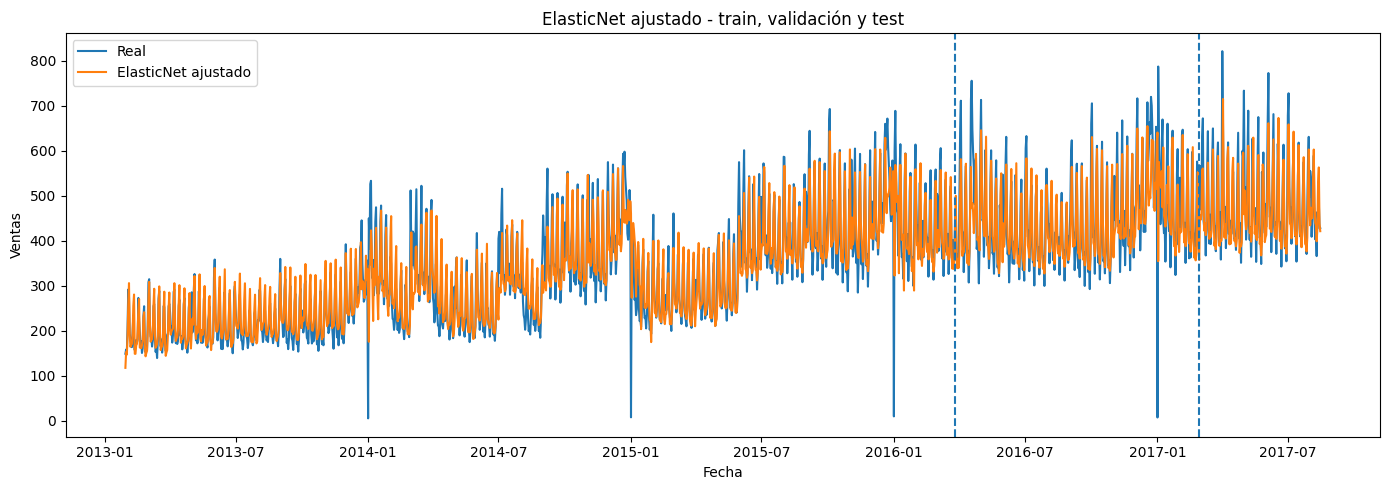

In [ ]:
################ GRAFICA DEL MEJOR MODELO ################

busqueda_elastic = RandomizedSearchCV(
    estimator=modelos["ElasticNet"],
    param_distributions=parametros["ElasticNet"],
    n_iter=10,
    cv=tscv,
    scoring="neg_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

busqueda_elastic.fit(X_train, y_train)
best_elastic = busqueda_elastic.best_estimator_

y_pred_train_elastic = best_elastic.predict(X_train)
y_pred_val_elastic = best_elastic.predict(X_val)
y_pred_test_elastic = best_elastic.predict(X_test)

fechas_all = pd.concat([
    train_model["date"],
    val_model["date"],
    test_model["date"]
], ignore_index=True)

y_real_all = pd.concat([
    y_train,
    y_val,
    y_test
], ignore_index=True)

y_pred_all = np.concatenate([
    y_pred_train_elastic,
    y_pred_val_elastic,
    y_pred_test_elastic
])

corte_train = train_model["date"].iloc[-1]
corte_val = val_model["date"].iloc[-1]

plt.figure(figsize=(14, 5))
plt.plot(fechas_all, y_real_all, label="Real")
plt.plot(fechas_all, y_pred_all, label="ElasticNet ajustado")

plt.axvline(corte_train, linestyle="--")
plt.axvline(corte_val, linestyle="--")

plt.title("ElasticNet ajustado - train, validación y test")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.legend()
plt.tight_layout()
plt.show()

Gráfica final de los datos de las ventas ajustando el mejor modelo del estudio, como se puede observar es un muy buen modelo para estimar las ventas.

### Conclusiones

1. El mejor modelo fue ElasticNet, con RMSE = 57.72 y  R2=0.63 en test, por lo que fue el que mejor logró estimar las ventas futuras a partir del comportamiento pasado de las ventas.

2. El modelo que se esperaba que fuera el mejor, XGBoost, no fue el mejor en este caso específico; por lo tanto, esto muestra la importancia de probar varios modelos y de optimizar sus hiperparámetros antes de elegir el modelo final.

3. El sobreajuste limita bastante la capacidad de pronóstico de los modelos, por lo tanto es importante revisar bien los datos, hacer una buena separación entre entrenamiento, validación y test, y verificar que el modelo realmente generalice bien fuera de muestra.


## Bibliografía

- scikit-learn developers. *Lasso*. Scikit-learn documentation.
- scikit-learn developers. *Linear Models (Ridge, Lasso, Elastic Net)*. Scikit-learn User Guide.
- scikit-learn developers. *RandomForestRegressor*. Scikit-learn documentation.
- XGBoost developers. *XGBoost Documentation*. Official documentation.
- XGBoost developers. *XGBoost Parameters*. Official documentation.
- scikit-learn developers. *MLPRegressor*. Scikit-learn documentation.
- scikit-learn developers. *Neural network models (supervised)*. Scikit-learn User Guide.